# Clinical Trial Disease Category Classification Using NLP and Machine Learning

**Domain:** Healthcare Analytics, Medical NLP & Clinical Trial Intelligence Systems

This notebook follows the 7-step approach from the project brief:
1. Data Collection
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. NLP-Based Disease Classification
5. Disease Prediction System
6. Application Development & Visualization (built separately as `app.py` for Streamlit)
7. Insights & Reporting

**Target column:** `source_condition_query` (disease category)
**Text column used for NLP:** `brief_summary`


## 0. Setup & Imports

In [1]:
# If running for the first time, uncomment and run this cell to install dependencies
# !pip install pandas numpy scikit-learn nltk matplotlib seaborn plotly wordcloud joblib streamlit


In [2]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

# Model persistence
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [3]:
# Download required NLTK resources (run once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 1. Data Collection
- Import the clinical trial dataset in CSV format
- Load the dataset into Python using Pandas DataFrame
- Understand the dataset structure, columns, and data types
- Select the "Brief Summary" column for NLP-based analysis
- Identify disease category labels for classification


In [ ]:
# Load dataset
DATA_PATH = "clinical_trials_raw_patient2trial_conditions.csv"  
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (60337, 16)


,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 60337 entries, 0 to 60336
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   source_condition_query  60337 non-null  str   
 1   nct_id                  60337 non-null  str   
 2   title                   60337 non-null  str   
 3   official_title          59551 non-null  str   
 4   brief_summary           60337 non-null  str   
 5   conditions              60336 non-null  str   
 6   interventions           54276 non-null  str   
 7   overall_status          60337 non-null  str   
 8   study_type              60337 non-null  str   
 9   phase                   23336 non-null  str   
 10  sex                     60304 non-null  str   
 11  minimum_age             57121 non-null  str   
 12  maximum_age             28400 non-null  str   
 13  healthy_volunteers      58857 non-null  object
 14  eligibility_criteria    60326 non-null  str   
 15  clinicaltrial

In [6]:
# Disease category label lives in 'source_condition_query'
# Text used for NLP classification lives in 'brief_summary'
print("Disease categories (target labels):")
print(df['source_condition_query'].unique())
print("\nNumber of categories:", df['source_condition_query'].nunique())


Disease categories (target labels):
<ArrowStringArray>
[                        'breast cancer',
                              'covid-19',
 'chronic obstructive pulmonary disease',
                  'rheumatoid arthritis',
                       'type 2 diabetes',
                              'glaucoma',
                               'anxiety',
                    'sickle cell anemia']
Length: 8, dtype: str

Number of categories: 8


## 2. Data Preprocessing
- Handle missing values and remove duplicate records
- Perform text cleaning and normalization
- Remove stop words, punctuation, and special characters
- Apply tokenization and lemmatization techniques
- Convert text data into numerical format using TF-IDF Vectorization
- Encode target labels for machine learning models


In [7]:
# Missing values overview
print(df.isnull().sum())


source_condition_query        0
nct_id                        0
title                         0
official_title              786
brief_summary                 0
conditions                    1
interventions              6061
overall_status                0
study_type                    0
phase                     37001
sex                          33
minimum_age                3216
maximum_age               31937
healthy_volunteers         1480
eligibility_criteria         11
clinicaltrials_url            0
dtype: int64


In [8]:
# Keep only the columns we actually need for this NLP task
df_model = df[['nct_id', 'brief_summary', 'source_condition_query']].copy()

# Drop duplicate trials (by nct_id) and rows with missing text/label
df_model = df_model.drop_duplicates(subset=['nct_id'])
df_model = df_model.dropna(subset=['brief_summary', 'source_condition_query'])
df_model = df_model.reset_index(drop=True)

print("Shape after cleaning:", df_model.shape)


Shape after cleaning: (60337, 3)


In [9]:
# Text cleaning + normalization function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\S+', ' ', text)        # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)               # remove punctuation/numbers/special chars
    text = re.sub(r'\s+', ' ', text).strip()            # remove extra whitespace

    tokens = word_tokenize(text)                       # tokenization
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens
              if tok not in stop_words and len(tok) > 2]  # stopword removal + lemmatization
    return ' '.join(tokens)

# Quick test
print(clean_text(df_model['brief_summary'].iloc[0]))


breast cancer patient often perioperative emotional disorder anxiety depression lead poor quality recovery study aim determine whether ketamine could improve quality recovery breast cancer patient meanwhile show ketamine could improve anxiety depression postoperative pain fatigue trial also bring great concern patient mental health perioperatively explore measure improve quality life


In [10]:
# Apply cleaning to the full dataset (this may take a couple of minutes on 60k rows)
df_model['clean_summary'] = df_model['brief_summary'].apply(clean_text)
df_model[['brief_summary', 'clean_summary']].head()


,brief_summary,clean_summary
0,Breast cancer patients often have perioperativ...,breast cancer patient often perioperative emot...
1,Many breast cancer patients experience psychol...,many breast cancer patient experience psycholo...
2,"Based on an American study by Scherer et al., ...",based american study scherer hypothesized woma...
3,Compare the effect of ropivacaine versus place...,compare effect ropivacaine versus placebo pect...
4,Phase 1 dose escalation and expansion study of...,phase dose escalation expansion study clsp fir...


In [11]:
# Remove any rows that became empty after cleaning
df_model = df_model[df_model['clean_summary'].str.strip() != ''].reset_index(drop=True)

# Encode target labels
label_encoder = LabelEncoder()
df_model['label_encoded'] = label_encoder.fit_transform(df_model['source_condition_query'])

print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))


{'anxiety': 0, 'breast cancer': 1, 'chronic obstructive pulmonary disease': 2, 'covid-19': 3, 'glaucoma': 4, 'rheumatoid arthritis': 5, 'sickle cell anemia': 6, 'type 2 diabetes': 7}


In [12]:
# Save the cleaned dataset (deliverable: Cleaned and Preprocessed Dataset)
df_model.to_csv('clinical_trials_cleaned.csv', index=False)
print("Saved clinical_trials_cleaned.csv")


Saved clinical_trials_cleaned.csv


## 3. Exploratory Data Analysis (EDA)
- Analyze the distribution of disease categories
- Identify the most common medical conditions and keywords
- Explore relationships between clinical trial summaries and disease categories
- Identify patterns, trends, and correlations in medical text data
- Perform statistical summaries and text-based analysis
- Visualize category distributions and word frequency patterns


In [13]:
# Disease category distribution
category_counts = df_model['source_condition_query'].value_counts()
print(category_counts)

fig = px.bar(category_counts, x=category_counts.index, y=category_counts.values,
             labels={'x': 'Disease Category', 'y': 'Number of Trials'},
             title='Distribution of Clinical Trials by Disease Category')
fig.show()


source_condition_query
breast cancer                            16301
type 2 diabetes                          11467
covid-19                                 10153
anxiety                                   9286
chronic obstructive pulmonary disease     6181
rheumatoid arthritis                      3637
glaucoma                                  2173
sickle cell anemia                        1139
Name: count, dtype: int64


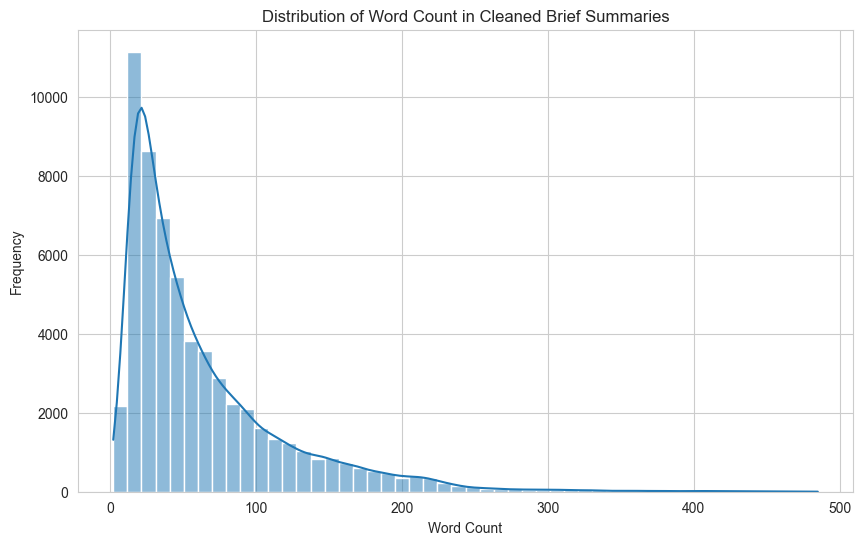

count    60337.000000
mean        62.515074
std         56.834576
min          2.000000
25%         23.000000
50%         43.000000
75%         82.000000
max        485.000000
Name: word_count, dtype: float64


In [14]:
# Text length distribution (word count of cleaned summaries)
df_model['word_count'] = df_model['clean_summary'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_model['word_count'], bins=50, kde=True)
plt.title('Distribution of Word Count in Cleaned Brief Summaries')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

print(df_model['word_count'].describe())


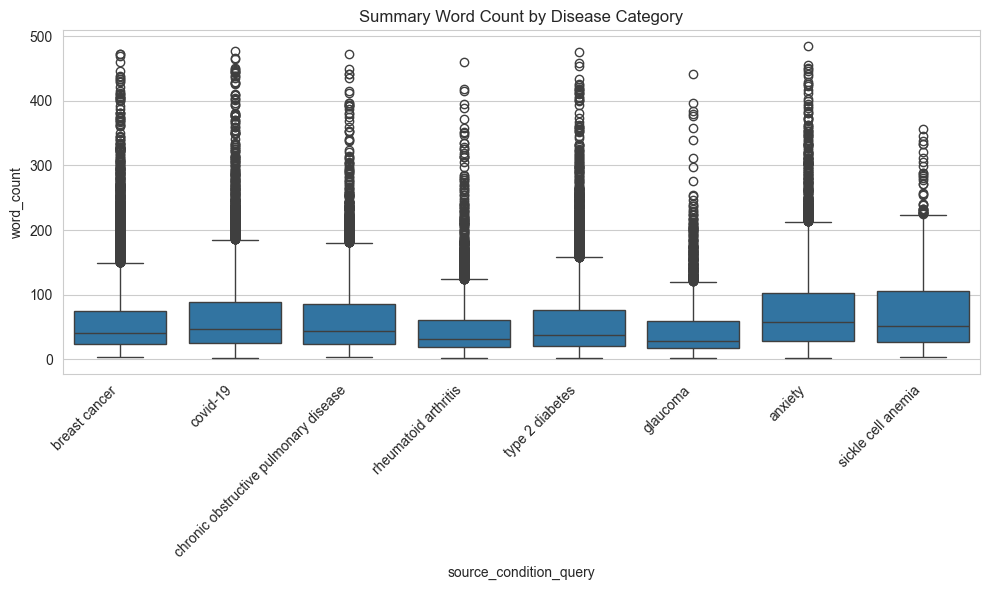

In [15]:
# Average summary length per disease category
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_model, x='source_condition_query', y='word_count')
plt.xticks(rotation=45, ha='right')
plt.title('Summary Word Count by Disease Category')
plt.tight_layout()
plt.show()


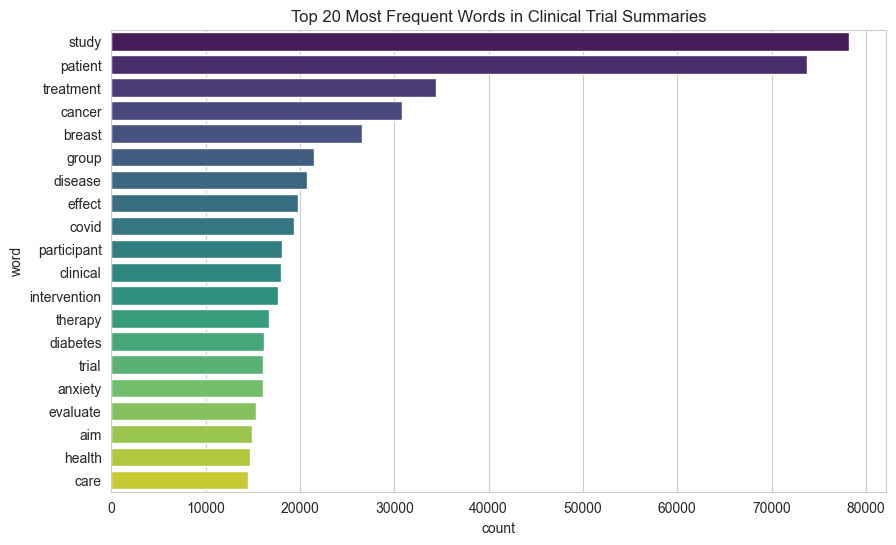

In [16]:
# Most frequent words overall
from collections import Counter

all_words = ' '.join(df_model['clean_summary']).split()
word_freq = Counter(all_words)
top_words = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words, x='count', y='word', palette='viridis')
plt.title('Top 20 Most Frequent Words in Clinical Trial Summaries')
plt.show()


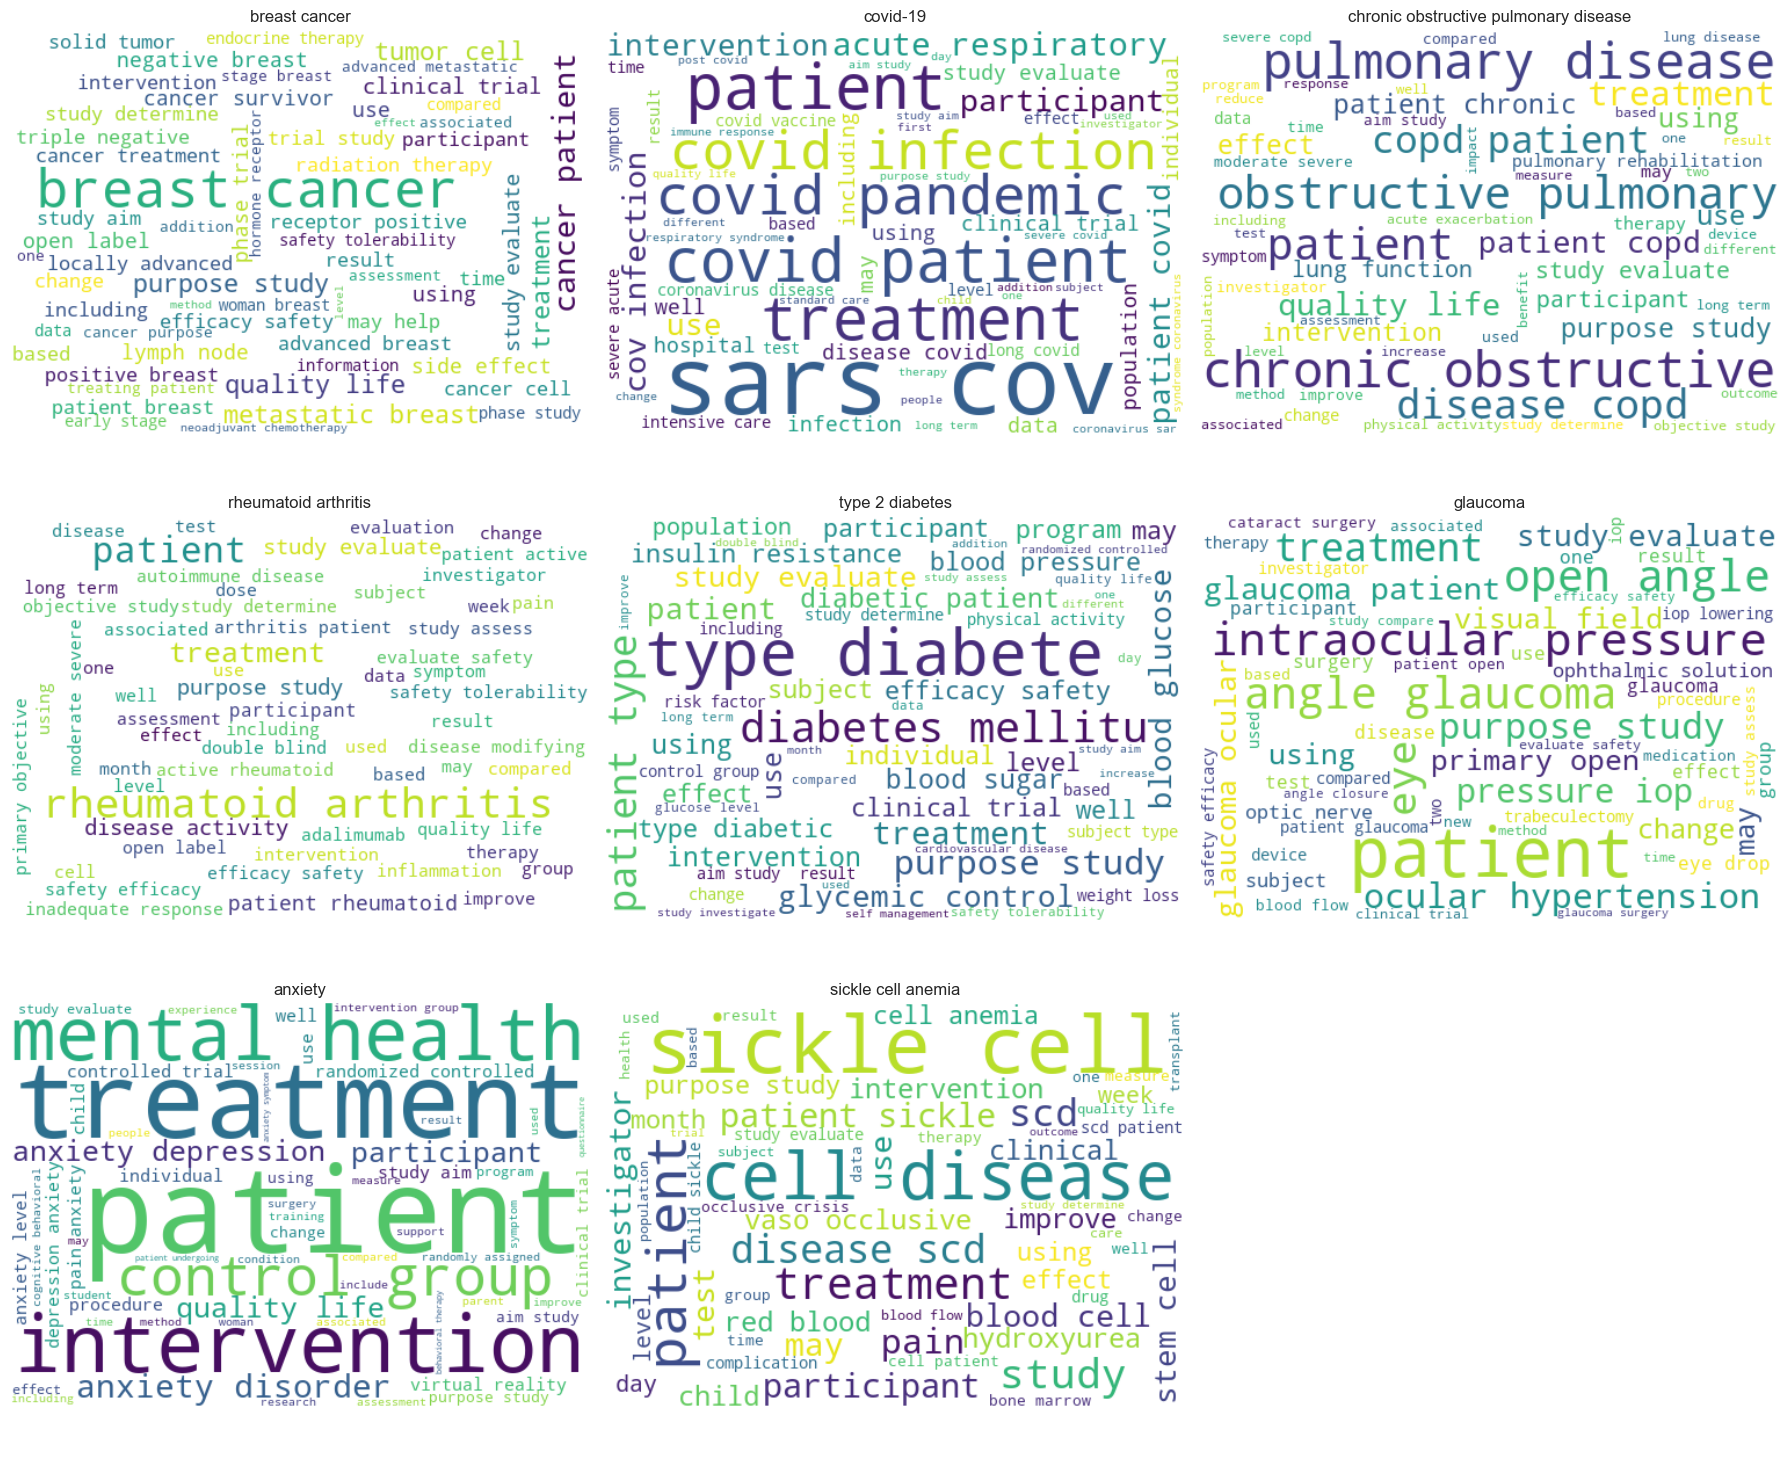

In [17]:
# Word clouds per disease category
categories = df_model['source_condition_query'].unique()
n = len(categories)
cols = 3
rows = -(-n // cols)  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, cat in enumerate(categories):
    text = ' '.join(df_model[df_model['source_condition_query'] == cat]['clean_summary'])
    wc = WordCloud(width=500, height=350, background_color='white', max_words=60).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(cat)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [18]:
# Most distinctive keywords per category (simple frequency-based, non-TFIDF view)
for cat in categories:
    cat_words = ' '.join(df_model[df_model['source_condition_query'] == cat]['clean_summary']).split()
    common = Counter(cat_words).most_common(10)
    print(f"\n{cat.upper()}:")
    print(', '.join([w for w, c in common]))



BREAST CANCER:
cancer, breast, patient, study, treatment, tumor, therapy, chemotherapy, cell, woman

COVID-19:
covid, patient, study, cov, sars, infection, disease, clinical, treatment, vaccine

CHRONIC OBSTRUCTIVE PULMONARY DISEASE:
patient, copd, study, disease, chronic, pulmonary, treatment, obstructive, lung, effect

RHEUMATOID ARTHRITIS:
study, patient, arthritis, rheumatoid, disease, treatment, safety, clinical, week, evaluate

TYPE 2 DIABETES:
diabetes, study, patient, type, insulin, glucose, treatment, blood, effect, control

GLAUCOMA:
glaucoma, study, patient, eye, pressure, iop, angle, ocular, intraocular, treatment

ANXIETY:
anxiety, study, patient, group, intervention, treatment, effect, pain, participant, health

SICKLE CELL ANEMIA:
cell, sickle, study, patient, disease, scd, blood, pain, treatment, child


## 4. NLP-Based Disease Classification
- Apply Natural Language Processing (NLP) techniques
- Convert medical text into numerical features using TF-IDF Vectorization
- Train machine learning models for disease category prediction
- Classify clinical trial summaries into disease categories
- Compare multiple classification algorithms for performance analysis
- Visualize model performance using evaluation metrics and plots


In [19]:
# Train / test split
X = df_model['clean_summary']
y = df_model['source_condition_query']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 48269  Test size: 12068


In [20]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)


TF-IDF matrix shape (train): (48269, 5000)


In [21]:
# Train and compare multiple classification algorithms
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    print(f"{name}: Accuracy={acc:.4f}, F1={f1:.4f}")

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df


Logistic Regression: Accuracy=0.9439, F1=0.9438
Multinomial Naive Bayes: Accuracy=0.8992, F1=0.8995
Linear SVM: Accuracy=0.9460, F1=0.9459
Random Forest: Accuracy=0.9415, F1=0.9412


,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.945973,0.946410,0.945973,0.945940
1,Logistic Regression,0.943901,0.944694,0.943901,0.943764
2,Random Forest,0.941498,0.942496,0.941498,0.941230
3,Multinomial Naive Bayes,0.899155,0.904599,0.899155,0.899539


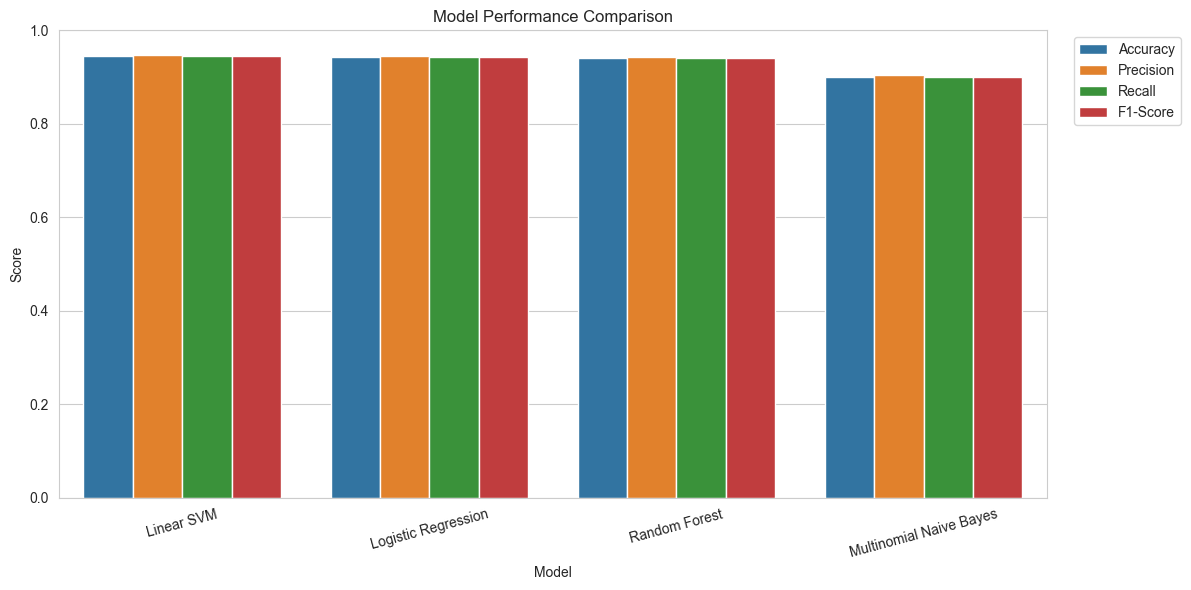

In [22]:
# Visualize model comparison
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [23]:
# Pick the best model (highest F1-score) and inspect it in detail
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print("Best model:", best_model_name)

best_preds = best_model.predict(X_test_tfidf)
print(classification_report(y_test, best_preds))


Best model: Linear SVM
                                       precision    recall  f1-score   support

                              anxiety       0.91      0.96      0.93      1857
                        breast cancer       0.96      0.97      0.97      3260
chronic obstructive pulmonary disease       0.91      0.91      0.91      1236
                             covid-19       0.97      0.95      0.96      2031
                             glaucoma       0.96      0.94      0.95       435
                 rheumatoid arthritis       0.93      0.88      0.90       727
                   sickle cell anemia       0.99      0.86      0.92       228
                      type 2 diabetes       0.95      0.95      0.95      2294

                             accuracy                           0.95     12068
                            macro avg       0.95      0.93      0.94     12068
                         weighted avg       0.95      0.95      0.95     12068



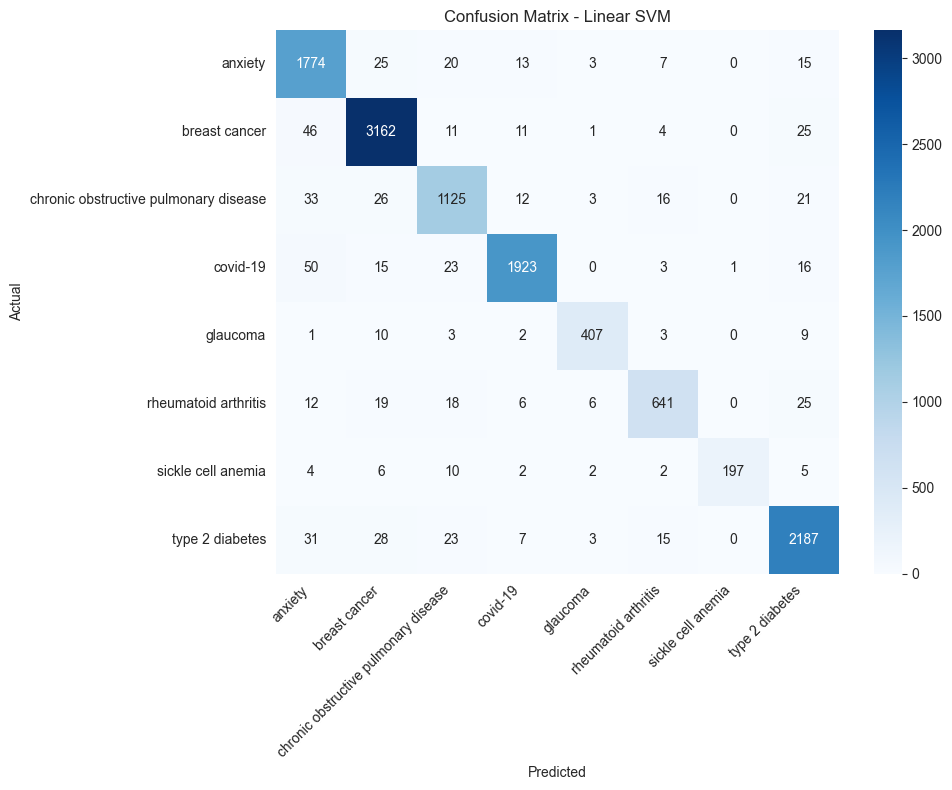

In [24]:
# Confusion matrix for the best model
cm = confusion_matrix(y_test, best_preds, labels=best_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 5. Disease Prediction System
- Build a machine learning-based disease classification system
- Use clinical trial "Brief Summary" text data
- Apply NLP techniques such as TF-IDF Vectorization
- Predict disease categories based on medical text input
- Validate prediction accuracy and model performance


In [25]:
def predict_disease(raw_text, model=best_model, vectorizer=tfidf, top_n=3):
    """Predict the disease category for a raw clinical trial summary,
    and return the top-N most likely categories with their probabilities
    (probabilities only available for models that implement predict_proba)."""
    cleaned = clean_text(raw_text)
    vec = vectorizer.transform([cleaned])
    prediction = model.predict(vec)[0]

    result = {'prediction': prediction}

    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(vec)[0]
        top_idx = np.argsort(proba)[::-1][:top_n]
        result['top_predictions'] = [(model.classes_[i], round(float(proba[i]), 4)) for i in top_idx]

    return result


In [26]:
# Example / validation
sample_text = df['brief_summary'].sample(1, random_state=7).values[0]
print("Sample text:\n", sample_text[:400], "...\n")
print(predict_disease(sample_text))


Sample text:
 This study is to find out about whether two sessions of psilocybin-assisted psychotherapy are safe and will help people who are anxious as a result of having stage IV melanoma and will involve two sessions of psychotherapy combined with either 4 or 25 mg psilocybin. The study will measure anxiety, depression, quality of life and spirituality before and after psilocybin-assisted psychotherapy, natu ...

{'prediction': 'anxiety'}


In [27]:
# Save the trained model, vectorizer (and label list) for reuse in the Streamlit app
joblib.dump(best_model, 'disease_classifier_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(sorted(df_model['source_condition_query'].unique().tolist()), 'disease_categories.pkl')

print("Saved: disease_classifier_model.pkl, tfidf_vectorizer.pkl, disease_categories.pkl")


Saved: disease_classifier_model.pkl, tfidf_vectorizer.pkl, disease_categories.pkl


## 7. Insights & Reporting
- Disease category distribution
- Frequently occurring medical terms
- Clinical trial text patterns and trends
- Model performance and prediction accuracy


In [28]:
print("="*70)
print("INSIGHTS SUMMARY")
print("="*70)

print(f"\n1. Dataset: {df_model.shape[0]} clinical trials across {df_model['source_condition_query'].nunique()} disease categories")

print("\n2. Category distribution:")
for cat, cnt in category_counts.items():
    pct = 100 * cnt / category_counts.sum()
    print(f"   - {cat}: {cnt} trials ({pct:.1f}%)")

print(f"\n3. Average cleaned summary length: {df_model['word_count'].mean():.1f} words "
      f"(min={df_model['word_count'].min()}, max={df_model['word_count'].max()})")

print(f"\n4. Top 10 overall keywords: {', '.join([w for w, c in word_freq.most_common(10)])}")

print(f"\n5. Best performing model: {best_model_name}")
print(results_df.to_string(index=False))


INSIGHTS SUMMARY

1. Dataset: 60337 clinical trials across 8 disease categories

2. Category distribution:
   - breast cancer: 16301 trials (27.0%)
   - type 2 diabetes: 11467 trials (19.0%)
   - covid-19: 10153 trials (16.8%)
   - anxiety: 9286 trials (15.4%)
   - chronic obstructive pulmonary disease: 6181 trials (10.2%)
   - rheumatoid arthritis: 3637 trials (6.0%)
   - glaucoma: 2173 trials (3.6%)
   - sickle cell anemia: 1139 trials (1.9%)

3. Average cleaned summary length: 62.5 words (min=2, max=485)

4. Top 10 overall keywords: study, patient, treatment, cancer, breast, group, disease, effect, covid, participant

5. Best performing model: Linear SVM
                  Model  Accuracy  Precision   Recall  F1-Score
             Linear SVM  0.945973   0.946410 0.945973  0.945940
    Logistic Regression  0.943901   0.944694 0.943901  0.943764
          Random Forest  0.941498   0.942496 0.941498  0.941230
Multinomial Naive Bayes  0.899155   0.904599 0.899155  0.899539
